# Englacial temperature with spatially varying conductivity_inf

This notebook estimates depth averaged ice temperature from radar attenuation, like `englacial_temperature.ipynb`, but uses a spatially varying borehole conductivity field instead of a single borehole average.

## Setting up the inversion equation

### What the radar measures

Two-way attenuation rate $N_a$ in dB/km maps to the high frequency limit conductivity $\sigma_\infty$ at the in-situ ice temperature $T$ via

$$
N_a(\sigma) = \frac{1000 \cdot (10\log_{10} e)}{c\,\epsilon_0\,\sqrt{\epsilon_r}}\,\sigma_\infty(T)
\quad\Longleftrightarrow\quad
\sigma_\infty(T) = N_a \cdot \frac{c\,\epsilon_0\,\sqrt{\epsilon_r}}{1000 \cdot (10\log_{10} e)}.
$$

The left-hand side is the high-frequency-limit conductivity at the unknown radar implied temperature $T$.

### What the borehole gives us

`conductivity_inf [S/m]` in the impurity files is $\sigma_\infty$. This column is the combined pure ice and impurity contributions into a single number per depth, evaluated at the borehole's in-situ temperature $T_{\mathrm{borehole}}(z)$.

Depth averaging both profiles gives one $(\bar\sigma_{\infty,\mathrm{borehole}},\,\bar T_{\mathrm{borehole}})$ pair per borehole: a known value of $\sigma_\infty$ at a known temperature.

### The Arrhenius formulation

$\sigma_\infty$ is assumed to follow a single Arrhenius law with effective activation energy $E_{\mathrm{cond}}$:

$$
\sigma_\infty(T) = \sigma_\infty(T_{\mathrm{ref}})\,\exp\!\left[\frac{E_{\mathrm{cond}}}{k_B}\left(\frac{1}{T_{\mathrm{ref}}}-\frac{1}{T}\right)\right].
$$

This needs only two things: a value of $\sigma_\infty$ at some known temperature, and that temperature as $T_{\mathrm{ref}}$. It does not care which temperature. The existing `cond` mode in `englacial_temperature.ipynb` reads $\sigma_\infty$ at 258 K from columns like `conductivity_258[S/m]`. Here, $\sigma_\infty$ is reported at the borehole's in-situ temperature, so $T_{\mathrm{ref}} = \bar T_{\mathrm{borehole}}$. Same equation, different anchor temperature.

Note that this collapses what chem mode treats as three species-specific Arrhenius terms (pure ice, $H^+$, ssCl, each with its own $E$) into one effective $E_{\mathrm{cond}}$ acting on the total. That is the price of working from $\sigma_\infty$ directly: you cannot recover the per-species temperature dependence from the sum.

### What the inversion solves

Setting the radar derived $\sigma_\infty(T)$ equal to the Arrhenius shifted borehole anchor and solving for $T$:

$$
\underbrace{N_a \cdot \frac{c\,\epsilon_0\,\sqrt{\epsilon_r}}{1000 \cdot (10\log_{10} e)}}_{\sigma_\infty(T)\text{ from radar}}
= \underbrace{\bar\sigma_{\infty,\mathrm{borehole}}}_{\sigma_\infty(\bar T_{\mathrm{borehole}})}
\,\exp\!\left[\frac{E_{\mathrm{cond}}}{k_B}\left(\frac{1}{\bar T_{\mathrm{borehole}}}-\frac{1}{T}\right)\right].
$$

`brentq` finds the $T$ where the two sides match. Chemistry never appears explicitly — it is already baked into $\bar\sigma_{\infty,\mathrm{borehole}}$.

## Making chemistry spatially varying

`englacial_temperature.ipynb` uses a single borehole's depth average for every attenuation pixel. Here, for every Antarctic borehole that has both `*_imp.csv` (with `conductivity_inf [S/m]`) and `*_temp.csv` (with `temp [C]`) the notebook will:

1. Compute the depth averaged $\sigma_\infty$ from `conductivity_inf [S/m]`
2. Compute the depth averaged borehole temperature $\bar T_{\mathrm{borehole}}$ from `temp [C]`
3. Krige both fields across Antarctica using `OrdinaryKriging`
4. At every attenuation pixel, query the kriged $\bar\sigma_{\infty,\mathrm{borehole}}$ and $\bar T_{\mathrm{borehole}}$, then invert the equation above for $T$

This is structurally identical to the `cond` mode in `englacial_temperature.ipynb`, just with per-pixel $\bar T_{\mathrm{borehole}}$ as $T_{\mathrm{ref}}$ and per-pixel $\bar\sigma_{\infty,\mathrm{borehole}}$ as the anchor.

## Cases compared

1. **Kriged**: $\bar\sigma_{\infty,\mathrm{borehole}}$ and $\bar T_{\mathrm{borehole}}$ kriged from all available boreholes, varying per pixel
2. **WAIS Divide only**: depth averaged WAIS Divide $\bar\sigma_{\infty,\mathrm{borehole}}$ and $\bar T_{\mathrm{borehole}}$ applied uniformly
3. **Pure ice**: no chemistry or conductivity, pure ice baseline

For the example WAIS Divide grid here, cases 1 and 2 should be very similar because WAIS Divide is the nearest borehole. They will diverge in other parts of the ice sheet.

## Imports

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from pykrige.ok import OrdinaryKriging

plt.rcParams["figure.dpi"] = 140

import sys
sys.path.append("../src")
import atten_temp_functions

## Configuration

In [ ]:
# File paths
attenuation_data = Path("../data/FullDataSet_Randomized.txt")
borehole_dir = Path("../AntarcticaBoreholeData")
loc_file = borehole_dir / "BoreholeLocations.csv"

# Attenuation CSV columns. Already in EPSG:3031 polar stereographic.
att_x_col = "x"
att_y_col = "y"
att_rate_col = "atten_rate_C0"

# Borehole used for the single borehole comparison case
single_borehole_name = "WAISDivide"  # matches subdir under borehole_dir

# Model parameter overrides. Tref is set per pixel from the borehole temperature
# field for the kriged case, and from the single borehole average for the WAIS case.
func_kwargs = {
    "sigma0": 6.6e-6,
    "Epure": 0.55 * 1.602176634e-19,
    "E_cond": 0.22 * 1.602176634e-19,
}

## Load attenuation rates

In [3]:
att_df = pd.read_csv(attenuation_data)
print("attenuation rows:", len(att_df))
att_df.head()

attenuation rows: 1642011


,x,y,aggregate_power,peak_power,atten_rate_C0,atten_rate_C.25,atten_uncertainty_C0,atten_uncertainty_C.25,reflectivity,reflectivity_sensitivity_test,reflectivity_variability,scattering_error
0,-1.208555e+06,-578181.65135,104.865172,94.542784,7.542318,0.632382,8.994948,0.696764,-11.005804,-11.816787,NaN,3.472389
1,-1.208551e+06,-578197.38140,102.898135,91.002152,7.542318,0.632382,8.994948,0.696764,-12.934520,-13.738122,NaN,5.045983
2,-1.208543e+06,-578228.85235,104.072383,93.956148,7.542318,0.632382,8.994948,0.696764,-11.703500,-12.496168,NaN,3.266235
3,-1.208535e+06,-578260.31135,102.281378,90.493025,7.542318,0.632382,8.994948,0.696764,-13.477697,-14.267128,NaN,4.938353
4,-1.208531e+06,-578276.04100,103.322084,92.818979,7.542318,0.632382,8.994948,0.696764,-12.490315,-13.290016,NaN,3.653105


## Build per borehole averages

For every borehole subdir that has both an `*_imp.csv` (with `conductivity_inf [S/m]`) and a `*_temp.csv` (with `temp [C]`), depth average each profile and pair with the borehole's lat/lon.

In [4]:
def depth_average(depth, vals):
    depth = np.asarray(depth, dtype=float)
    vals = np.asarray(vals, dtype=float)
    mask = np.isfinite(depth) & np.isfinite(vals)
    depth = depth[mask]
    vals = vals[mask]
    order = np.argsort(depth)
    depth = depth[order]
    vals = vals[order]
    return np.trapz(vals, depth) / (depth[-1] - depth[0])

loc_data = pd.read_csv(loc_file)
loc_data["name_lc"] = loc_data["Name"].str.lower()

imp_files = sorted(glob.glob(str(borehole_dir / "**" / "*_imp.csv"), recursive=True))

records = []
for imp_path in imp_files:
    imp_path = Path(imp_path)
    sample_name = imp_path.stem.split("_")[0]

    temp_candidates = list(imp_path.parent.glob("*_temp.csv"))
    if not temp_candidates:
        print(f"skip {sample_name}: no temp file")
        continue
    temp_path = temp_candidates[0]

    imp_df = pd.read_csv(imp_path)
    temp_df = pd.read_csv(temp_path)

    cond_cols = [c for c in imp_df.columns if "conductivity_inf" in c.lower()]
    depth_imp_cols = [c for c in imp_df.columns if "depth" in c.lower()]
    depth_temp_cols = [c for c in temp_df.columns if "depth" in c.lower()]
    temp_cols = [c for c in temp_df.columns if "temp" in c.lower() and "depth" not in c.lower()]

    if not (cond_cols and depth_imp_cols and depth_temp_cols and temp_cols):
        print(f"skip {sample_name}: missing required columns")
        continue

    avg_cond = depth_average(imp_df[depth_imp_cols[0]], imp_df[cond_cols[0]])
    avg_temp_C = depth_average(temp_df[depth_temp_cols[0]], temp_df[temp_cols[0]])
    avg_temp_K = avg_temp_C + 273.15

    match = loc_data[loc_data["name_lc"] == sample_name.lower()]
    if match.empty:
        print(f"skip {sample_name}: no location row")
        continue
    row = match.iloc[0]

    records.append({
        "name": row["Name"],
        "lat": float(row["Lat"]),
        "lon": float(row["Lon"]),
        "sigma_inf_Sm": float(avg_cond),
        "T_borehole_K": float(avg_temp_K),
    })
    print(f"{row['Name']:<20s} sigma_inf={avg_cond:.3e} S/m  T_avg={avg_temp_C:.2f} C")

bh_records = pd.DataFrame(records)
bh_records

DomeC                sigma_inf=6.284e-06 S/m  T_avg=-32.88 C
skip simpledome: no location row
TaylorDome           sigma_inf=7.827e-06 S/m  T_avg=-32.97 C
Vostok               sigma_inf=8.792e-06 S/m  T_avg=-35.11 C
WAISDivide           sigma_inf=6.380e-06 S/m  T_avg=-27.44 C


,name,lat,lon,sigma_inf_Sm,T_borehole_K
0,DomeC,-75.100000,123.4000,0.000006,240.269472
1,TaylorDome,-77.666667,158.0000,0.000008,240.181933
2,Vostok,-78.466700,106.8000,0.000009,238.043368
3,WAISDivide,-79.467600,-112.0865,0.000006,245.714801


## Krige $\sigma_\infty$ and $T_{\mathrm{borehole}}$ onto the attenuation grid

Both fields are kriged from the borehole point set onto every attenuation pixel.

In [5]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031")
bh_x, bh_y = transformer.transform(bh_records["lat"].to_numpy(), bh_records["lon"].to_numpy())
bh_records["x"] = bh_x
bh_records["y"] = bh_y

att_x = att_df[att_x_col].to_numpy()
att_y = att_df[att_y_col].to_numpy()

OK_cond = OrdinaryKriging(
    bh_records["x"].to_numpy(),
    bh_records["y"].to_numpy(),
    bh_records["sigma_inf_Sm"].to_numpy(),
    variogram_model="linear",
    verbose=False,
    enable_plotting=False,
)
OK_temp = OrdinaryKriging(
    bh_records["x"].to_numpy(),
    bh_records["y"].to_numpy(),
    bh_records["T_borehole_K"].to_numpy(),
    variogram_model="linear",
    verbose=False,
    enable_plotting=False,
)

sigma_inf_pix, _ = OK_cond.execute("points", att_x, att_y)
T_borehole_pix_K, _ = OK_temp.execute("points", att_x, att_y)
sigma_inf_pix = np.asarray(sigma_inf_pix, dtype=float)
T_borehole_pix_K = np.asarray(T_borehole_pix_K, dtype=float)

print("sigma_inf range:", np.nanmin(sigma_inf_pix), np.nanmax(sigma_inf_pix))
print("T_borehole range [K]:", np.nanmin(T_borehole_pix_K), np.nanmax(T_borehole_pix_K))

sigma_inf range: 6.3809692957739845e-06 6.69685140904498e-06
T_borehole range [K]: 244.94492704640246 245.71250003766187


## Case 1: kriged $\sigma_\infty$ and $T_{\mathrm{borehole}}$ (per pixel)

Each pixel uses its own kriged $\sigma_\infty$ as `cond` and its own kriged $T_{\mathrm{borehole}}$ as `Tref`. This loops the inversion per pixel since `attenRateToTemperature` takes scalar `cond` and `Tref`.

In [6]:
rates = att_df[att_rate_col].to_numpy()

Tavg_kriged_K = np.full(rates.shape, np.nan)
for i in range(rates.size):
    r = rates[i]
    c = sigma_inf_pix[i]
    Tref_i = T_borehole_pix_K[i]
    if not (np.isfinite(r) and np.isfinite(c) and np.isfinite(Tref_i) and c > 0):
        continue
    Tavg_kriged_K[i] = atten_temp_functions.attenRateToTemperature(
        r,
        cond=c,
        Tref=Tref_i,
        **func_kwargs,
    )

Tavg_kriged_C = Tavg_kriged_K - 273.15
print("kriged Tavg [C] range:", np.nanmin(Tavg_kriged_C), np.nanmax(Tavg_kriged_C))

kriged Tavg [C] range: -116.28982903825448 41.408960077242796


## Case 2: single borehole (WAIS Divide only)

Use the depth averaged WAIS Divide $\sigma_\infty$ and $T_{\mathrm{borehole}}$ as scalar inputs for every attenuation pixel.

In [7]:
wais_row = bh_records[bh_records["name"].str.lower() == single_borehole_name.lower()]
if wais_row.empty:
    raise ValueError(f"borehole {single_borehole_name} not found in records")
wais_sigma_inf = float(wais_row["sigma_inf_Sm"].iloc[0])
wais_T_K = float(wais_row["T_borehole_K"].iloc[0])
print(f"WAIS Divide sigma_inf = {wais_sigma_inf:.3e} S/m")
print(f"WAIS Divide T_borehole = {wais_T_K:.2f} K ({wais_T_K - 273.15:.2f} C)")

Tavg_wais_K = atten_temp_functions.attenRateToTemperature(
    rates,
    cond=wais_sigma_inf,
    Tref=wais_T_K,
    **func_kwargs,
)
Tavg_wais_K = np.asarray(Tavg_wais_K, dtype=float)
Tavg_wais_K[~np.isfinite(rates)] = np.nan
Tavg_wais_C = Tavg_wais_K - 273.15

WAIS Divide sigma_inf = 6.380e-06 S/m
WAIS Divide T_borehole = 245.71 K (-27.44 C)


## Case 3: pure ice (no chemistry/conductivity)

In [8]:
Tavg_pure_K = atten_temp_functions.attenRateToTemperature(
    rates,
    **func_kwargs,
)
Tavg_pure_K = np.asarray(Tavg_pure_K, dtype=float)
Tavg_pure_K[~np.isfinite(rates)] = np.nan
Tavg_pure_C = Tavg_pure_K - 273.15

## Mapped outputs

Top row: depth averaged temperature for each of the three cases.

Bottom row: kriged $\sigma_\infty$ field, kriged $T_{\mathrm{borehole}}$ field, and the difference between the kriged and WAIS Divide only temperatures (should be near zero in this region).

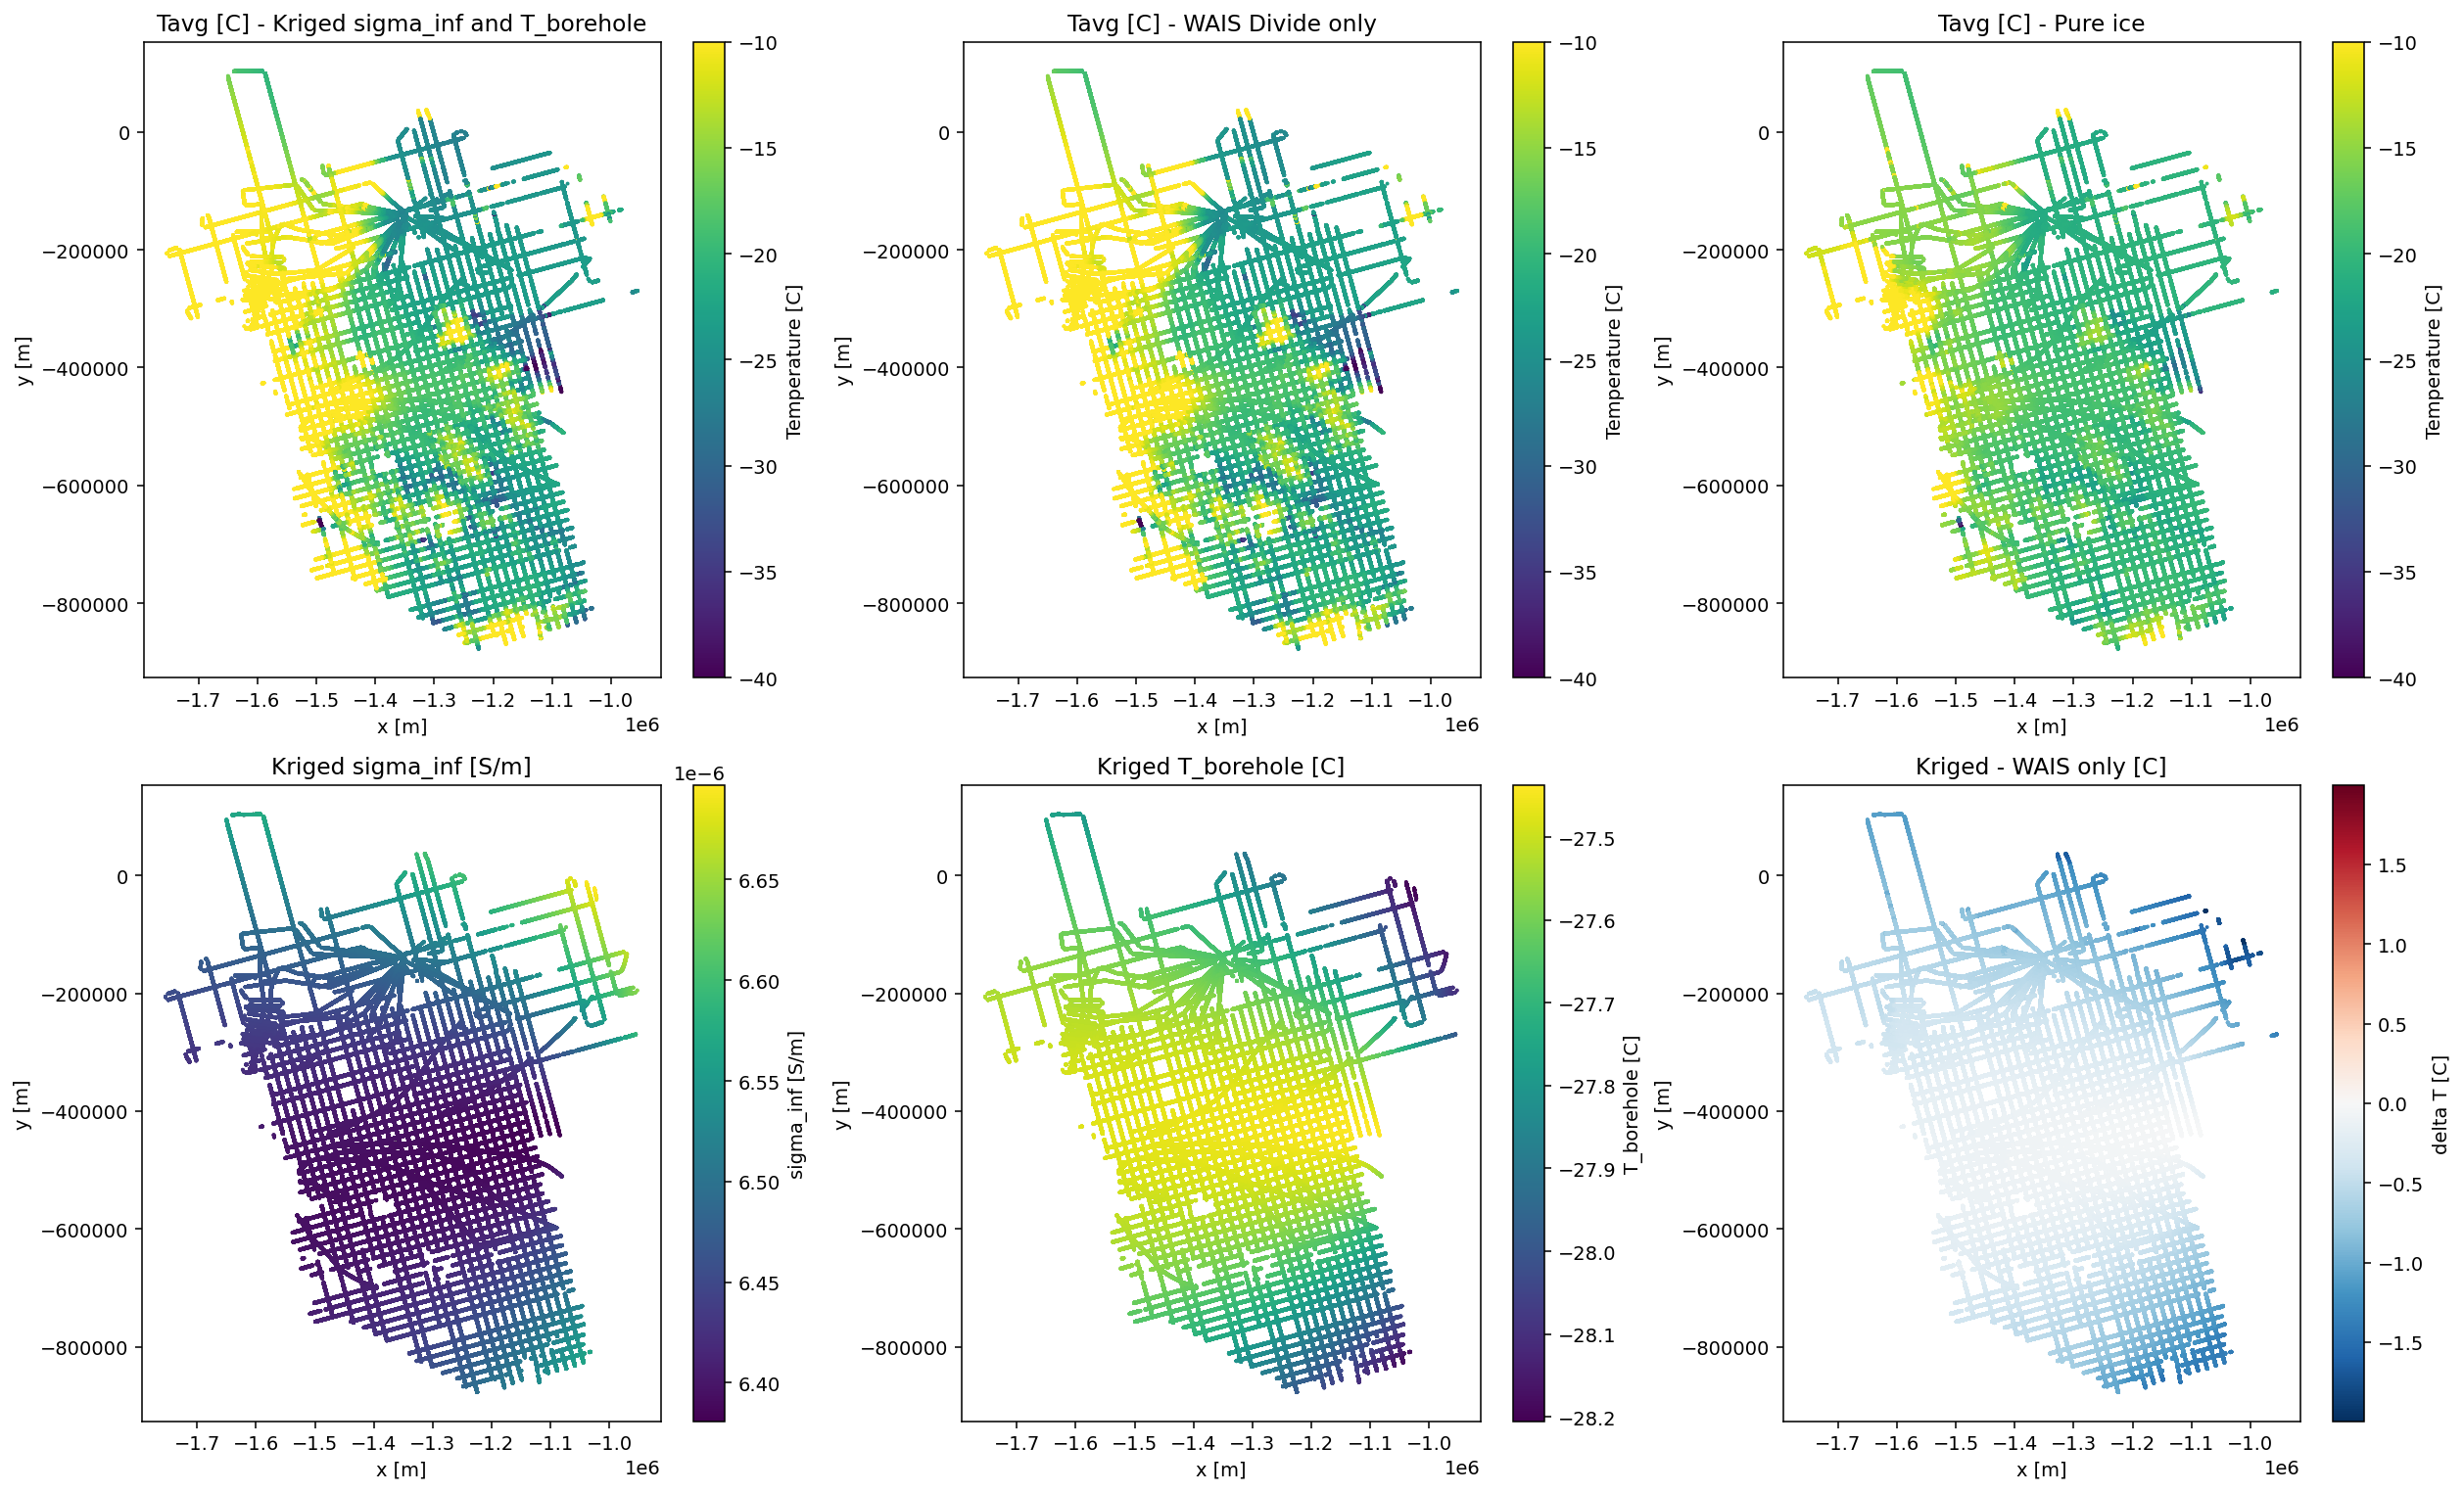

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

T_vmin, T_vmax = -40, -10

panels_top = [
    ("Kriged sigma_inf and T_borehole", Tavg_kriged_C),
    ("WAIS Divide only", Tavg_wais_C),
    ("Pure ice", Tavg_pure_C),
]

for ax, (title, vals) in zip(axes[0], panels_top):
    sc = ax.scatter(att_x, att_y, c=vals, s=1, vmin=T_vmin, vmax=T_vmax)
    ax.set_title(f"Tavg [C] - {title}")
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    plt.colorbar(sc, ax=ax, label="Temperature [C]")

sc = axes[1, 0].scatter(att_x, att_y, c=sigma_inf_pix, s=1)
axes[1, 0].set_title("Kriged sigma_inf [S/m]")
axes[1, 0].set_aspect("equal")
axes[1, 0].set_xlabel("x [m]")
axes[1, 0].set_ylabel("y [m]")
plt.colorbar(sc, ax=axes[1, 0], label="sigma_inf [S/m]")

sc = axes[1, 1].scatter(att_x, att_y, c=T_borehole_pix_K - 273.15, s=1)
axes[1, 1].set_title("Kriged T_borehole [C]")
axes[1, 1].set_aspect("equal")
axes[1, 1].set_xlabel("x [m]")
axes[1, 1].set_ylabel("y [m]")
plt.colorbar(sc, ax=axes[1, 1], label="T_borehole [C]")

diff = Tavg_kriged_C - Tavg_wais_C
vmax = np.nanmax(np.abs(diff)) if np.any(np.isfinite(diff)) else 1.0
sc = axes[1, 2].scatter(att_x, att_y, c=diff, s=1, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1, 2].set_title("Kriged - WAIS only [C]")
axes[1, 2].set_aspect("equal")
axes[1, 2].set_xlabel("x [m]")
axes[1, 2].set_ylabel("y [m]")
plt.colorbar(sc, ax=axes[1, 2], label="delta T [C]")

plt.tight_layout()
plt.show()

## Histograms of the three temperature solutions

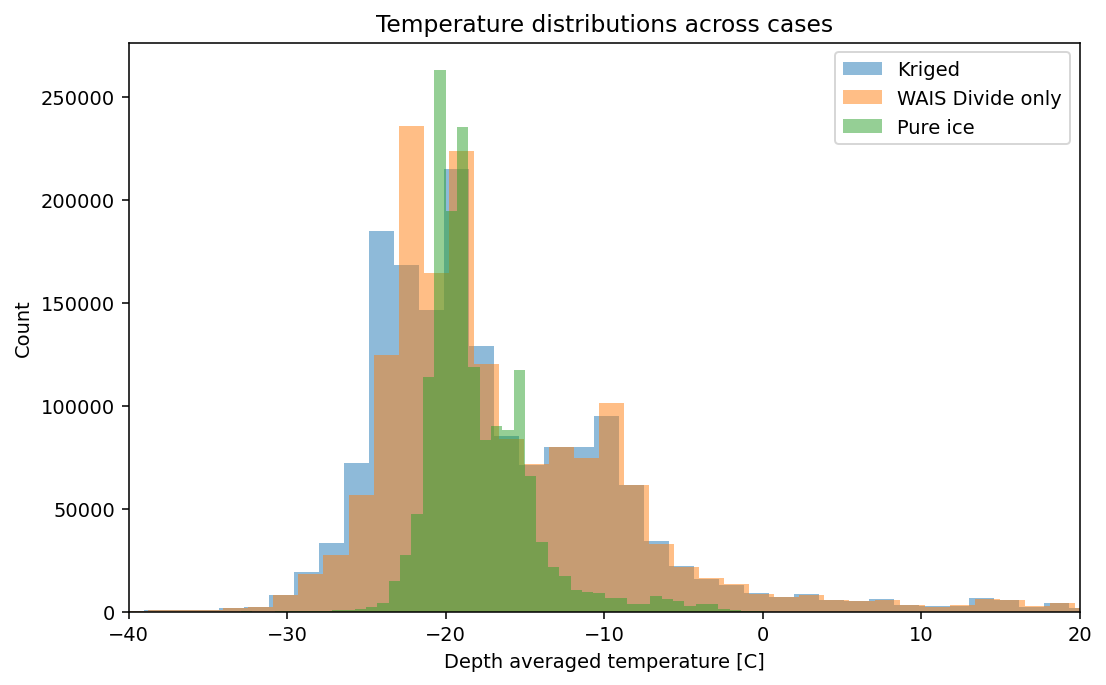

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, vals in [
    ("Kriged", Tavg_kriged_C),
    ("WAIS Divide only", Tavg_wais_C),
    ("Pure ice", Tavg_pure_C),
]:
    finite = np.asarray(vals)[np.isfinite(vals)]
    ax.hist(finite, bins=100, alpha=0.5, label=label)
ax.set_xlabel("Depth averaged temperature [C]")
ax.set_xlim([-40,20])
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Temperature distributions across cases")
plt.tight_layout()
plt.show()